# AquaVision: Water Quality Index Prediction
## Part 1: Comprehensive Data Preprocessing and Exploratory Data Analysis

### Project Overview
This project focuses on assessing water quality using the Water Quality Index (WQI) and developing a predictive model for WQI scores. We'll leverage a comprehensive dataset comprising various water parameters such as pH, dissolved oxygen, turbidity, and pollutant levels.

### Phase 1 Goals:
- Load and explore the raw dataset
- Identify and handle missing values using advanced imputation techniques
- Detect and manage outliers and anomalies
- Validate data integrity
- Transform and normalize features
- Conduct statistical analysis and feature correlation studies

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Statistical and ML libraries
from scipy import stats
from scipy.stats import shapiro, anderson, mannwhitneyu, f_oneway
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, confusion_matrix, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import seasonal_decompose
import missingno as msno

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset and Initial Exploration

In [2]:
# Load the dataset
df = pd.read_csv('../data/water_quality_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total Records: {len(df)}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*80)
print("DATA TYPES")
print("="*80)
print(df.dtypes)

print("\n" + "="*80)
print("FIRST FEW RECORDS")
print("="*80)
display(df.head(10))

DATASET OVERVIEW
Shape: (730, 21)
Date Range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00
Total Records: 730

Memory Usage: 0.16 MB

DATA TYPES
Date                        datetime64[ns]
Location                            object
pH                                 float64
Dissolved_Oxygen_mg_L              float64
Turbidity_NTU                      float64
Conductivity_uS_cm                 float64
Temperature_C                      float64
Hardness_mg_L                      float64
Chloride_mg_L                      float64
Ammonia_mg_L                       float64
Nitrate_mg_L                       float64
Phosphate_mg_L                     float64
Iron_mg_L                          float64
Manganese_mg_L                     float64
Sulfate_mg_L                       float64
Total_Coliform_CFU_100mL           float64
E_Coli_CFU_100mL                   float64
BOD_mg_L                           float64
COD_mg_L                           float64
WQI                                float

,Date,Location,pH,Dissolved_Oxygen_mg_L,Turbidity_NTU,Conductivity_uS_cm,Temperature_C,Hardness_mg_L,Chloride_mg_L,Ammonia_mg_L,...,Phosphate_mg_L,Iron_mg_L,Manganese_mg_L,Sulfate_mg_L,Total_Coliform_CFU_100mL,E_Coli_CFU_100mL,BOD_mg_L,COD_mg_L,WQI,Potability
0,2022-01-01,Rural_West,7.482338,15.0,4.170814,616.250653,18.558003,241.061185,28.790228,1.525627,...,3.992936,0.320624,0.145774,115.222583,56.714662,2.838827,3.985388,5.856630,83.643410,1
1,2022-01-02,Industrial,8.455687,15.0,6.030984,539.517417,24.630370,226.215027,35.706811,0.430293,...,1.632670,-0.046101,0.122157,147.151716,72.195549,0.177216,1.029208,13.302791,85.808143,1
2,2022-01-03,Rural_East,7.162338,15.0,0.000000,588.990826,20.776868,218.961881,28.305594,1.327389,...,4.169908,0.450739,0.263872,105.303584,240.959142,9.655018,1.084971,4.464752,87.268357,1
3,2022-01-04,Industrial,5.502368,15.0,0.000000,285.217374,32.911535,228.672212,16.016990,0.781989,...,3.908738,0.325899,0.359340,209.872069,21.186291,6.123221,4.583362,9.674546,88.889142,1
4,2022-01-05,Industrial,7.492561,15.0,4.981082,464.746529,28.146333,170.306641,49.955744,1.185384,...,0.893038,0.088923,0.052899,85.309132,26.469917,8.373976,1.055942,4.561808,85.307743,1
5,2022-01-06,Urban_South,7.983743,15.0,0.000000,442.075799,22.051559,142.507415,77.025967,0.824435,...,4.184238,0.659813,0.192480,195.050266,9.053321,22.960009,2.481888,4.326653,95.449499,1
6,2022-01-07,Rural_East,8.847213,15.0,4.013241,236.699021,35.466976,121.175555,41.030311,-0.119701,...,2.074628,0.230683,0.041361,223.425114,11.412394,35.040801,0.860457,11.423788,89.993093,1
7,2022-01-08,Rural_East,5.770565,15.0,0.195180,615.759109,29.539974,114.639000,27.362068,-0.760272,...,1.751573,0.243671,0.200164,169.086237,59.109751,10.063608,5.094535,1.537394,93.242780,1
8,2022-01-09,Rural_East,7.352506,15.0,7.903881,327.389865,12.731614,252.729521,48.737194,0.904958,...,2.080970,0.428342,0.072182,143.127472,124.473205,14.441591,0.351292,3.307002,81.228150,1
9,2022-01-10,Industrial,7.409636,15.0,4.201267,358.564826,34.857627,150.411309,56.782364,0.668132,...,2.494741,0.676800,0.271155,162.314091,25.093703,0.875298,5.306121,2.030598,88.233662,1


## 3. Missing Values Analysis

In [3]:
# Comprehensive missing values analysis
print("="*80)
print("MISSING VALUES SUMMARY")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
}).sort_values('Missing_Count', ascending=False)

display(missing_data[missing_data['Missing_Count'] > 0])

print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
print(f"Columns with Missing Values: {(df.isnull().sum() > 0).sum()}")

# Explanation of missing values pattern
print("\n" + "="*80)
print("MISSING VALUES EXPLANATION")
print("="*80)
print("""
Observation: Multiple columns have identical missing counts (21 values, 2.88%)

Reason: This is by design in the data generation process. 
- The 4 columns (Phosphate, Manganese, Ammonia, Iron) represent sensor measurements
- Each sensor independently fails or is unavailable approximately 3% of the time
- This is realistic - different sensors have independent availability patterns
- 3% of 730 records = 21.9 ≈ 21 rows per column
- The indices are randomized, so the missing rows are different for each sensor
- This pattern represents realistic IoT sensor behavior

Next Step: We will use KNN imputation to intelligently 
fill these missing values based on neighboring records.
""")

MISSING VALUES SUMMARY


,Column,Missing_Count,Missing_Percentage,Data_Type
Phosphate_mg_L,Phosphate_mg_L,21,2.88,float64
Manganese_mg_L,Manganese_mg_L,21,2.88,float64
Ammonia_mg_L,Ammonia_mg_L,21,2.88,float64
Iron_mg_L,Iron_mg_L,21,2.88,float64



Total Missing Values: 84
Columns with Missing Values: 4

MISSING VALUES EXPLANATION

Observation: Multiple columns have identical missing counts (21 values, 2.88%)

Reason: This is by design in the data generation process. 
- The 4 columns (Phosphate, Manganese, Ammonia, Iron) represent sensor measurements
- Each sensor independently fails or is unavailable approximately 3% of the time
- This is realistic - different sensors have independent availability patterns
- 3% of 730 records = 21.9 ≈ 21 rows per column
- The indices are randomized, so the missing rows are different for each sensor
- This pattern represents realistic IoT sensor behavior

Next Step: We will use KNN imputation to intelligently 
fill these missing values based on neighboring records.



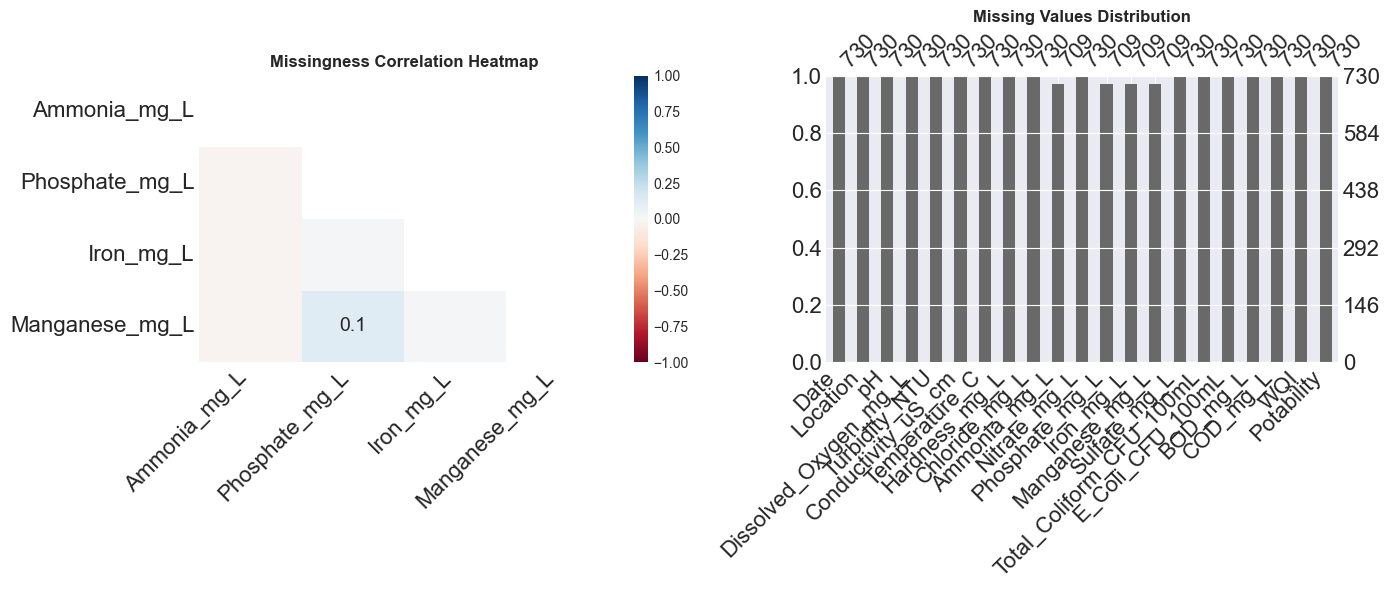

Missing values visualizations generated


In [4]:
# Visualization of missing values
fig = plt.figure(figsize=(14, 6))

# Missing values heatmap
plt.subplot(1, 2, 1)
msno.heatmap(df, ax=plt.gca())
plt.title('Missingness Correlation Heatmap', fontsize=12, fontweight='bold')

# Missing values matrix
plt.subplot(1, 2, 2)
msno.bar(df, ax=plt.gca())
plt.title('Missing Values Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Missing values visualizations generated")

## 4. Imputation Strategy and Implementation

In [5]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Potability')  # Remove target variable from feature list
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric Features ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

# Create a copy for imputation comparison
df_imputed_knn = df.copy()

# KNN Imputation (k=5 nearest neighbors)
print("\n" + "="*80)
print("Performing KNN Imputation (k=5)...")
print("="*80)

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_imputed_knn[numeric_cols] = knn_imputer.fit_transform(df_imputed_knn[numeric_cols])

print(f"KNN Imputation completed")
print(f"  Remaining missing values: {df_imputed_knn.isnull().sum().sum()}")

Numeric Features (18): ['pH', 'Dissolved_Oxygen_mg_L', 'Turbidity_NTU', 'Conductivity_uS_cm', 'Temperature_C']...
Categorical Features (1): ['Location']

Performing KNN Imputation (k=5)...
KNN Imputation completed
  Remaining missing values: 0


In [6]:
# Mean Imputation as comparison
df_imputed_mean = df.copy()
mean_imputer = SimpleImputer(strategy='mean')
df_imputed_mean[numeric_cols] = mean_imputer.fit_transform(df_imputed_mean[numeric_cols])

# Use KNN imputed data for further analysis
df_clean = df_imputed_knn.copy()

print(f"Mean Imputation completed")
print(f"\nUsing KNN imputed data for further analysis")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Mean Imputation completed

Using KNN imputed data for further analysis
Remaining missing values: 0


## 5. Outlier Detection and Analysis

In [7]:
# IQR-based outlier detection
print("="*80)
print("OUTLIER DETECTION: IQR Method")
print("="*80)

outliers_iqr = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    if outlier_count > 0:
        outliers_iqr[col] = {
            'count': outlier_count,
            'percentage': (outlier_count / len(df_clean) * 100).round(2),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

outlier_df = pd.DataFrame(outliers_iqr).T.sort_values('count', ascending=False)
print(f"\nColumns with outliers (IQR Method):")
display(outlier_df)

OUTLIER DETECTION: IQR Method

Columns with outliers (IQR Method):


,count,percentage,lower_bound,upper_bound
Dissolved_Oxygen_mg_L,167.0,22.88,15.000000,15.000000
Total_Coliform_CFU_100mL,47.0,6.44,-64.594775,143.543327
E_Coli_CFU_100mL,35.0,4.79,-15.044440,32.205154
BOD_mg_L,32.0,4.38,-4.442795,9.783526
COD_mg_L,25.0,3.42,-10.768693,23.915695
WQI,21.0,2.88,73.878237,98.653617
Manganese_mg_L,9.0,1.23,-0.118058,0.427042
Ammonia_mg_L,9.0,1.23,-0.618681,2.182734
Nitrate_mg_L,6.0,0.82,-15.655638,64.168025
Hardness_mg_L,5.0,0.68,19.077988,341.310683


In [8]:
# Z-score based outlier detection
print("\n" + "="*80)
print("OUTLIER DETECTION: Z-Score Method")
print("="*80)

z_scores = np.abs(stats.zscore(df_clean[numeric_cols]))
z_outliers = (z_scores > 3).sum()
z_outlier_cols = z_outliers[z_outliers > 0].sort_values(ascending=False)

print(f"\nZ-Score outliers (threshold > 3):")
display(z_outlier_cols)

print(f"\nTotal outlier records (Z-Score > 3): {(z_scores > 3).any(axis=1).sum()}")


OUTLIER DETECTION: Z-Score Method

Z-Score outliers (threshold > 3):


Dissolved_Oxygen_mg_L       26
BOD_mg_L                    19
COD_mg_L                    15
E_Coli_CFU_100mL            12
WQI                         11
Total_Coliform_CFU_100mL     9
Nitrate_mg_L                 3
Chloride_mg_L                3
Manganese_mg_L               3
Conductivity_uS_cm           2
Hardness_mg_L                2
Ammonia_mg_L                 2
Iron_mg_L                    2
Phosphate_mg_L               2
pH                           1
Sulfate_mg_L                 1
dtype: int64


Total outlier records (Z-Score > 3): 108


In [9]:
# Isolation Forest for anomaly detection
print("\n" + "="*80)
print("ANOMALY DETECTION: Isolation Forest")
print("="*80)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(df_clean[numeric_cols])
anomaly_scores = iso_forest.score_samples(df_clean[numeric_cols])

n_anomalies = (anomaly_labels == -1).sum()
print(f"\nAnomalies detected: {n_anomalies} ({(n_anomalies/len(df_clean)*100):.2f}%)")

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(df_clean[numeric_cols])
n_lof_anomalies = (lof_labels == -1).sum()
print(f"LOF Anomalies detected: {n_lof_anomalies} ({(n_lof_anomalies/len(df_clean)*100):.2f}%)")


ANOMALY DETECTION: Isolation Forest

Anomalies detected: 37 (5.07%)
LOF Anomalies detected: 37 (5.07%)


## 6. Statistical Distribution Analysis

In [10]:
# Normality tests
print("="*80)
print("NORMALITY TESTS")
print("="*80)

normality_results = []
for col in numeric_cols[:10]:  # Test first 10 numeric columns
    stat_shapiro, p_shapiro = shapiro(df_clean[col])
    stat_anderson = anderson(df_clean[col])
    
    normality_results.append({
        'Feature': col,
        'Shapiro_p': p_shapiro,
        'Normal_Shapiro': 'Yes' if p_shapiro > 0.05 else 'No',
        'Anderson_Stat': stat_anderson.statistic,
        'Skewness': stats.skew(df_clean[col]),
        'Kurtosis': stats.kurtosis(df_clean[col])
    })

normality_df = pd.DataFrame(normality_results)
display(normality_df)

NORMALITY TESTS


,Feature,Shapiro_p,Normal_Shapiro,Anderson_Stat,Skewness,Kurtosis
0,pH,6.323655e-12,No,4.466642,-0.436354,-0.409848
1,Dissolved_Oxygen_mg_L,2.499817e-41,No,164.693343,-2.768276,7.666609
2,Turbidity_NTU,7.063397e-11,No,3.668070,0.301208,-0.573413
3,Conductivity_uS_cm,6.360865e-01,Yes,0.479209,0.020784,-0.215330
4,Temperature_C,4.916445e-13,No,5.352243,-0.013294,-1.058412
5,Hardness_mg_L,5.960260e-01,Yes,0.386726,-0.019795,-0.044586
6,Chloride_mg_L,5.453365e-01,Yes,0.434053,-0.109374,0.142060
7,Ammonia_mg_L,6.171306e-01,Yes,0.412657,0.070992,0.056465
8,Nitrate_mg_L,8.528583e-01,Yes,0.187788,-0.014299,-0.046729
9,Phosphate_mg_L,9.400367e-01,Yes,0.217281,-0.015610,-0.130592


In [11]:
# Skewness and Kurtosis analysis
print("\n" + "="*80)
print("SKEWNESS AND KURTOSIS SUMMARY")
print("="*80)

skew_kurt = pd.DataFrame({
    'Feature': numeric_cols,
    'Skewness': [stats.skew(df_clean[col]) for col in numeric_cols],
    'Kurtosis': [stats.kurtosis(df_clean[col]) for col in numeric_cols],
    'Mean': df_clean[numeric_cols].mean(),
    'Std': df_clean[numeric_cols].std(),
    'Min': df_clean[numeric_cols].min(),
    'Max': df_clean[numeric_cols].max()
})

display(skew_kurt.sort_values('Skewness', key=abs, ascending=False).head(10))


SKEWNESS AND KURTOSIS SUMMARY


,Feature,Skewness,Kurtosis,Mean,Std,Min,Max
Dissolved_Oxygen_mg_L,Dissolved_Oxygen_mg_L,-2.768276,7.666609,14.593935,0.971693,8.375518,15.000000
COD_mg_L,COD_mg_L,2.457371,10.103346,7.856653,7.968322,0.004435,68.346003
Total_Coliform_CFU_100mL,Total_Coliform_CFU_100mL,1.987098,5.247649,49.477496,50.803731,0.066726,338.175266
E_Coli_CFU_100mL,E_Coli_CFU_100mL,1.701013,3.390149,10.093138,10.149756,0.014192,63.789851
BOD_mg_L,BOD_mg_L,1.684113,3.109096,3.080752,3.029281,0.003962,16.458592
WQI,WQI,-0.937658,2.422815,85.991511,5.179939,60.805251,98.528143
pH,pH,-0.436354,-0.409848,7.413333,1.094206,4.000000,9.000000
Turbidity_NTU,Turbidity_NTU,0.301208,-0.573413,4.045136,2.679412,0.000000,11.495873
Chloride_mg_L,Chloride_mg_L,-0.109374,0.142060,43.493471,19.818405,-26.641252,105.294234
Ammonia_mg_L,Ammonia_mg_L,0.070992,0.056465,0.787617,0.528984,-0.969429,2.420070


## 7. Feature Scaling and Transformation

In [12]:
# Apply multiple scaling techniques
print("="*80)
print("FEATURE SCALING")
print("="*80)

# Standard Scaler (Standardization)
scaler_standard = StandardScaler()
df_standard = df_clean.copy()
df_standard[numeric_cols] = scaler_standard.fit_transform(df_clean[numeric_cols])

# Min-Max Scaler (Normalization)
scaler_minmax = MinMaxScaler()
df_minmax = df_clean.copy()
df_minmax[numeric_cols] = scaler_minmax.fit_transform(df_clean[numeric_cols])

# Robust Scaler (resistant to outliers)
scaler_robust = RobustScaler()
df_robust = df_clean.copy()
df_robust[numeric_cols] = scaler_robust.fit_transform(df_clean[numeric_cols])

print("Standard Scaling completed (mean=0, std=1)")
print("Min-Max Scaling completed (range=[0,1])")
print("Robust Scaling completed (resistant to outliers)")

# Display sample of scaled data
print("\nSample of Standardized Data:")
display(df_standard[numeric_cols].head())

FEATURE SCALING
Standard Scaling completed (mean=0, std=1)
Min-Max Scaling completed (range=[0,1])
Robust Scaling completed (resistant to outliers)

Sample of Standardized Data:


,pH,Dissolved_Oxygen_mg_L,Turbidity_NTU,Conductivity_uS_cm,Temperature_C,Hardness_mg_L,Chloride_mg_L,Ammonia_mg_L,Nitrate_mg_L,Phosphate_mg_L,Iron_mg_L,Manganese_mg_L,Sulfate_mg_L,Total_Coliform_CFU_100mL,E_Coli_CFU_100mL,BOD_mg_L,COD_mg_L,WQI
0,0.063107,0.41818,0.046938,1.126312,-0.116304,1.033465,-0.742407,1.396104,1.485646,0.970348,0.095060,-0.084894,-0.686970,0.142551,-0.715218,0.298835,-0.251169,-0.453618
1,0.953265,0.41818,0.741659,0.609602,0.395159,0.785269,-0.393170,-0.675954,-0.166004,-0.569646,-1.677843,-0.321397,-0.026171,0.447480,-0.977631,-0.677702,0.683942,-0.035424
2,-0.229543,0.41818,-1.510745,0.942749,0.070586,0.664013,-0.766878,1.021094,0.511184,1.085817,0.724087,1.097743,-0.892251,3.771631,-0.043195,-0.659282,-0.425965,0.246667
3,-1.747637,0.41818,-1.510745,-1.102815,1.092664,0.826348,-1.387363,-0.010645,1.045022,0.915412,0.120558,2.053763,1.271876,-0.557254,-0.391402,0.496369,0.228296,0.559778
4,0.072457,0.41818,0.349550,0.106107,0.691301,-0.149397,0.326298,0.752462,-0.688720,-1.052231,-1.025081,-1.014948,-1.306052,-0.453182,-0.169496,-0.668871,-0.413776,-0.132094


In [13]:
# Power Transformation (Yeo-Johnson)
print("\n" + "="*80)
print("POWER TRANSFORMATION (Yeo-Johnson)")
print("="*80)

power_transformer = PowerTransformer(method='yeo-johnson')
df_power = df_clean.copy()
df_power[numeric_cols] = power_transformer.fit_transform(df_clean[numeric_cols])

print("Yeo-Johnson Power Transformation applied")
print("\nSkewness comparison (before vs after transformation):")
skew_comparison = pd.DataFrame({
    'Feature': numeric_cols[:10],
    'Skewness_Before': [stats.skew(df_clean[col]) for col in numeric_cols[:10]],
    'Skewness_After': [stats.skew(df_power[col]) for col in numeric_cols[:10]]
})
skew_comparison['Improvement'] = abs(skew_comparison['Skewness_Before']) - abs(skew_comparison['Skewness_After'])
display(skew_comparison)


POWER TRANSFORMATION (Yeo-Johnson)
Yeo-Johnson Power Transformation applied

Skewness comparison (before vs after transformation):


,Feature,Skewness_Before,Skewness_After,Improvement
0,pH,-0.436354,-0.088144,0.348210
1,Dissolved_Oxygen_mg_L,-2.768276,-1.513857,1.254419
2,Turbidity_NTU,0.301208,-0.126867,0.174341
3,Conductivity_uS_cm,0.020784,0.000018,0.020766
4,Temperature_C,-0.013294,-0.288731,-0.275437
5,Hardness_mg_L,-0.019795,-0.018970,0.000824
6,Chloride_mg_L,-0.109374,-0.036275,0.073099
7,Ammonia_mg_L,0.070992,0.006509,0.064483
8,Nitrate_mg_L,-0.014299,-0.022014,-0.007716
9,Phosphate_mg_L,-0.015610,-0.019789,-0.004179


## 8. Feature Engineering - Time-Based Features

In [14]:
# Extract temporal features
print("="*80)
print("TEMPORAL FEATURE ENGINEERING")
print("="*80)

df_features = df_clean.copy()

# Extract date components
df_features['Year'] = df_features['Date'].dt.year
df_features['Month'] = df_features['Date'].dt.month
df_features['Day'] = df_features['Date'].dt.day
df_features['DayOfWeek'] = df_features['Date'].dt.dayofweek
df_features['Quarter'] = df_features['Date'].dt.quarter
df_features['Week'] = df_features['Date'].dt.isocalendar().week

# Cyclical encoding for month (sine-cosine transformation)
df_features['Month_sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
df_features['Month_cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)

# Cyclical encoding for day of week
df_features['DayOfWeek_sin'] = np.sin(2 * np.pi * df_features['DayOfWeek'] / 7)
df_features['DayOfWeek_cos'] = np.cos(2 * np.pi * df_features['DayOfWeek'] / 7)

# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_features['Season'] = df_features['Month'].apply(get_season)

print("Temporal features engineered:")
print("  - Year, Month, Day, DayOfWeek, Quarter, Week")
print("  - Cyclical encoding: Month_sin, Month_cos, DayOfWeek_sin, DayOfWeek_cos")
print("  - Season (categorical)")
print(f"\nNew feature columns: {[col for col in df_features.columns if col not in df_clean.columns]}")
print(f"Total features now: {len(df_features.columns)}")

TEMPORAL FEATURE ENGINEERING
Temporal features engineered:
  - Year, Month, Day, DayOfWeek, Quarter, Week
  - Cyclical encoding: Month_sin, Month_cos, DayOfWeek_sin, DayOfWeek_cos
  - Season (categorical)

New feature columns: ['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Week', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Season']
Total features now: 32


## 9. Correlation and Multicollinearity Analysis

In [15]:
# Calculate correlation matrix
print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Pearson correlation
correlation_matrix = df_clean[numeric_cols].corr(method='pearson')

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature1': correlation_matrix.columns[i],
                'Feature2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
    display(high_corr_df)
else:
    print("\nNo highly correlated pairs found (|r| > 0.7)")

CORRELATION ANALYSIS

No highly correlated pairs found (|r| > 0.7)


In [16]:
# Variance Inflation Factor (VIF) Analysis
print("\n" + "="*80)
print("MULTICOLLINEARITY: Variance Inflation Factor (VIF)")
print("="*80)

# Standardize the data for VIF calculation
X_scaled = StandardScaler().fit_transform(df_clean[numeric_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF Interpretation:")
print("  VIF = 1: No correlation")
print("  VIF < 5: Generally acceptable")
print("  VIF > 10: High multicollinearity (consider removing)\n")
display(vif_data.head(15))


MULTICOLLINEARITY: Variance Inflation Factor (VIF)

VIF Interpretation:
  VIF = 1: No correlation
  VIF < 5: Generally acceptable
  VIF > 10: High multicollinearity (consider removing)



,Feature,VIF
17,WQI,2.103829
2,Turbidity_NTU,1.639348
7,Ammonia_mg_L,1.324333
13,Total_Coliform_CFU_100mL,1.145982
4,Temperature_C,1.067755
1,Dissolved_Oxygen_mg_L,1.063650
14,E_Coli_CFU_100mL,1.035463
12,Sulfate_mg_L,1.032955
0,pH,1.030519
5,Hardness_mg_L,1.029049


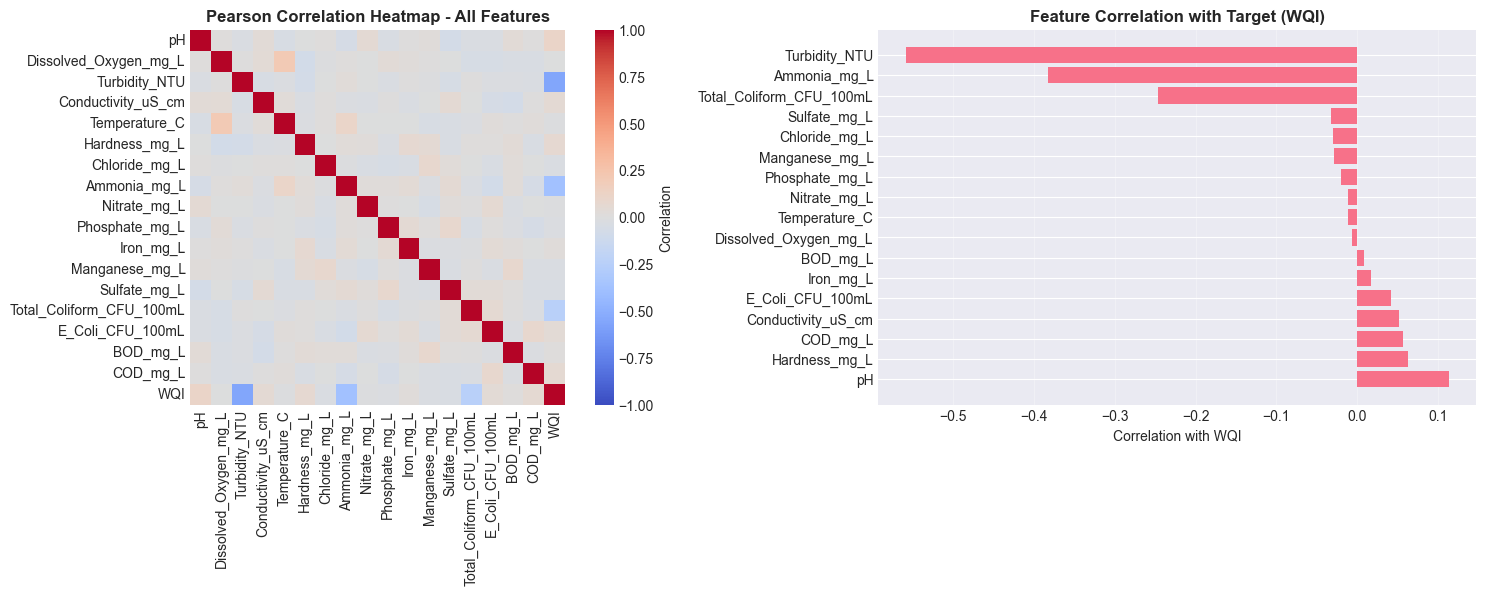

✓ Correlation visualizations generated


In [17]:
# Visualize correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, 
            cbar_kws={'label': 'Correlation'}, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation Heatmap - All Features', fontsize=12, fontweight='bold')

# Correlation with target variable (WQI)
feature_cols = [col for col in numeric_cols if col != 'WQI']
target_corr = df_clean[feature_cols + ['WQI']].corr()['WQI'].drop('WQI').sort_values(ascending=False)
axes[1].barh(range(len(target_corr)), target_corr.values)
axes[1].set_yticks(range(len(target_corr)))
axes[1].set_yticklabels(target_corr.index)
axes[1].set_xlabel('Correlation with WQI')
axes[1].set_title('Feature Correlation with Target (WQI)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Correlation visualizations generated")

## 10. Dimensionality Reduction - PCA

In [18]:
# Principal Component Analysis
print("="*80)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

# Standardize data for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[numeric_cols])

# Apply PCA with all components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1

print(f"\nTotal Components: {pca.n_components_}")
print(f"Components needed for 90% variance: {np.argmax(cumsum_variance >= 0.90) + 1}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Components needed for 99% variance: {np.argmax(cumsum_variance >= 0.99) + 1}")

print("\nTop 10 Principal Components - Explained Variance:")
var_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(10)],
    'Variance_Explained': pca.explained_variance_ratio_[:10],
    'Cumulative_Variance': cumsum_variance[:10]
})
display(var_df)

PRINCIPAL COMPONENT ANALYSIS (PCA)

Total Components: 18
Components needed for 90% variance: 16
Components needed for 95% variance: 17
Components needed for 99% variance: 18

Top 10 Principal Components - Explained Variance:


,PC,Variance_Explained,Cumulative_Variance
0,PC1,0.098853,0.098853
1,PC2,0.072213,0.171065
2,PC3,0.067917,0.238983
3,PC4,0.065791,0.304773
4,PC5,0.064093,0.368866
5,PC6,0.060546,0.429412
6,PC7,0.058208,0.487620
7,PC8,0.056726,0.544346
8,PC9,0.055893,0.600239
9,PC10,0.054245,0.654484


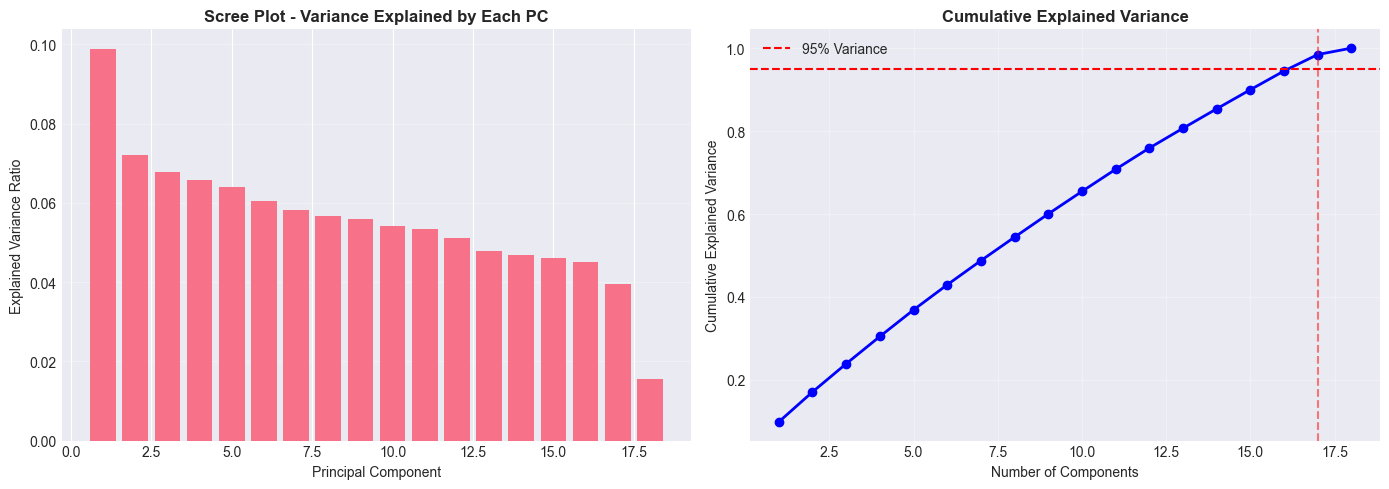

PCA analysis visualizations generated


In [19]:
# Scree plot and cumulative variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, min(21, len(pca.explained_variance_ratio_)+1)), 
            pca.explained_variance_ratio_[:20])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot - Variance Explained by Each PC', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance plot
axes[1].plot(range(1, min(21, len(cumsum_variance)+1)), cumsum_variance[:20], 'bo-', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].axvline(x=n_components_95, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("PCA analysis visualizations generated")

## 11. Statistical Analysis - Hypothesis Testing

In [20]:
# Analyze differences between potable and non-potable water
print("="*80)
print("COMPARATIVE STATISTICAL ANALYSIS: Potable vs Non-Potable Water")
print("="*80)

potable = df_clean[df_clean['Potability'] == 1]
non_potable = df_clean[df_clean['Potability'] == 0]

print(f"\nPotable samples: {len(potable)} ({len(potable)/len(df_clean)*100:.1f}%)")
print(f"Non-potable samples: {len(non_potable)} ({len(non_potable)/len(df_clean)*100:.1f}%)")

# Conduct t-tests
stats_results = []
for col in numeric_cols[:10]:
    if len(potable[col]) > 1 and len(non_potable[col]) > 1:
        t_stat, p_value = stats.ttest_ind(potable[col], non_potable[col])
        stats_results.append({
            'Feature': col,
            'Potable_Mean': potable[col].mean(),
            'NonPotable_Mean': non_potable[col].mean(),
            'T_Statistic': t_stat,
            'P_Value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })

stats_df = pd.DataFrame(stats_results)
display(stats_df)

COMPARATIVE STATISTICAL ANALYSIS: Potable vs Non-Potable Water

Potable samples: 721 (98.8%)
Non-potable samples: 9 (1.2%)


,Feature,Potable_Mean,NonPotable_Mean,T_Statistic,P_Value,Significant
0,pH,7.420246,6.859487,1.529338,0.126615,No
1,Dissolved_Oxygen_mg_L,14.591070,14.823486,-0.712882,0.476147,No
2,Turbidity_NTU,4.020575,6.012691,-2.222660,0.026545,Yes
3,Conductivity_uS_cm,449.314391,422.944819,0.528788,0.597114,No
4,Temperature_C,20.000204,15.021852,1.249795,0.211776,No
5,Hardness_mg_L,179.513307,157.591256,1.092064,0.275166,No
6,Chloride_mg_L,43.344325,55.441704,-1.822807,0.068743,No
7,Ammonia_mg_L,0.787893,0.765452,0.126398,0.899451,No
8,Nitrate_mg_L,24.149594,17.645716,1.286576,0.198651,No
9,Phosphate_mg_L,2.506125,2.474584,0.061271,0.951160,No


## 12. Summary and Data Quality Report

In [21]:
# Generate comprehensive data quality report
print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT REPORT")
print("="*80)

print("\nDATA OVERVIEW:")
print(f"  Total Records: {len(df_clean):,}")
print(f"  Total Features: {len(df_clean.columns)}")
print(f"  Numeric Features: {len(numeric_cols)}")
print(f"  Categorical Features: {len(categorical_cols)}")
print(f"  Date Range: {df_features['Date'].min().date()} to {df_features['Date'].max().date()}")

print("\nDATA PREPROCESSING STATUS:")
print(f"  Missing Values: Imputed using KNN (k=5)")
print(f"  Remaining Missing: {df_clean.isnull().sum().sum()}")
print(f"  Outliers Detected (IQR): {sum(1 for v in outliers_iqr.values() if v['count'] > 0)} features")
print(f"  Anomalies Detected (Isolation Forest): {n_anomalies} records ({(n_anomalies/len(df_clean)*100):.2f}%)")

print("\nFEATURE ENGINEERING:")
print(f"  Temporal Features Created: 9")
print(f"  Power Transformation Applied: Yeo-Johnson")
print(f"  Scaling Methods Available: StandardScaler, MinMaxScaler, RobustScaler")

print("\nDATA CHARACTERISTICS:")
print(f"  Highly Correlated Pairs (|r|>0.7): {len(high_corr_pairs)}")
print(f"  Features with High VIF (>10): {(vif_data['VIF'] > 10).sum()}")
print(f"  PCA: {n_components_95} components explain 95% variance")

print("\nData is ready for machine learning modeling!")
print("="*80)


DATA QUALITY ASSESSMENT REPORT

DATA OVERVIEW:
  Total Records: 730
  Total Features: 21
  Numeric Features: 18
  Categorical Features: 1
  Date Range: 2022-01-01 to 2023-12-31

DATA PREPROCESSING STATUS:
  Missing Values: Imputed using KNN (k=5)
  Remaining Missing: 0
  Outliers Detected (IQR): 16 features
  Anomalies Detected (Isolation Forest): 37 records (5.07%)

FEATURE ENGINEERING:
  Temporal Features Created: 9
  Power Transformation Applied: Yeo-Johnson
  Scaling Methods Available: StandardScaler, MinMaxScaler, RobustScaler

DATA CHARACTERISTICS:
  Highly Correlated Pairs (|r|>0.7): 0
  Features with High VIF (>10): 0
  PCA: 17 components explain 95% variance

Data is ready for machine learning modeling!


In [22]:
# Save preprocessed datasets for next stages
print("\nSaving preprocessed data...")

df_clean.to_csv('../outputs/01_data_cleaned.csv', index=False)
df_features.to_csv('../outputs/02_data_with_features.csv', index=False)
df_standard.to_csv('../outputs/03_data_standardized.csv', index=False)
df_minmax.to_csv('../outputs/04_data_minmax.csv', index=False)

print("Preprocessed data saved:")
print("  - 01_data_cleaned.csv (KNN imputed)")
print("  - 02_data_with_features.csv (engineered features)")
print("  - 03_data_standardized.csv (standardized)")
print("  - 04_data_minmax.csv (min-max scaled)")

print("\nPart 1 Complete! Proceed to Part 2: Feature Engineering & Modeling")


Saving preprocessed data...
Preprocessed data saved:
  - 01_data_cleaned.csv (KNN imputed)
  - 02_data_with_features.csv (engineered features)
  - 03_data_standardized.csv (standardized)
  - 04_data_minmax.csv (min-max scaled)

Part 1 Complete! Proceed to Part 2: Feature Engineering & Modeling
